# **SMS Spam & Scam Detection using a Transformer Encoder**

This project detects **scam / spam SMS messages** using a **Transformer Encoder built entirely from scratch** in PyTorch (custom scaled dot-product attention, multi-head attention, and encoder block). Self-attention lets the model weigh words in context to separate legitimate messages (`legit`) from unsolicited scam/spam (`scam`).

**Dataset: SMS Spam Collection (UCI Machine Learning Repository).**
A public benchmark of **5,574 real English SMS messages** labelled *ham* (legitimate) or *spam* (unsolicited / scam), collected by Almeida & Hidalgo (2011) and released under a CC BY 4.0 licence. Unlike a synthetic corpus, it contains **thousands of unique, naturally-written messages**, so the model must learn generalisable linguistic patterns rather than memorise a handful of templates.

*Kaggle:* `uciml/sms-spam-collection-dataset` · *Original:* UCI ML Repository, id 228 · *Citation:* Almeida, T. A. & Hidalgo, J. M. G. (2011).


# **Build the Core**
-------

# Execution Guide

Run the notebook **top to bottom**. The sections are ordered so that every variable a cell needs has already been created above it.

### 1. Environment
* **Platform:** Google Colab (metadata pre-configured). Enable a GPU via `Runtime > Change runtime type > T4 GPU`, the code automatically detects and uses it (`device`).
* The first code cell installs `kagglehub` to fetch the dataset.

### 2. Build & test the Transformer core
* Run the cells under **Build the Core** to define **Scaled Dot-Product Attention**, **Multi-Head Attention**, and the **Transformer Encoder Block** (Pre-LayerNorm + residual connections + feed-forward network).
* Run the **Unit Tests**, each prints a `passed` message and verifies tensor shapes, softmax normalisation, masking, and gradient flow.

### 3. Data, EDA & preprocessing
* **Load data:** downloads `spam.csv`, cleans columns, maps `ham/spam → legit/scam`, and **removes duplicate messages** to prevent train/test leakage.
* **EDA:** class balance, message-length distributions, and the most frequent words per class.
* **Preprocessing / feature engineering:** normalises URLs, e-mails, phone numbers, currency and digits into special tokens, then tokenises and builds a **train-only vocabulary** with a minimum-frequency cutoff. Messages that reduce to no tokens after cleaning (e.g. emoji-only replies) are mapped to `<UNK>`, so every input stays valid.

### 4. Dry run
* A quick pilot on a small stratified subset confirms the full pipeline (preprocess → forward pass → short training) runs end-to-end and the loss decreases.

### 5. Full training
* Stratified **80 / 10 / 10** train/val/test split, **class-weighted** loss to handle imbalance, and **best-checkpoint selection** on validation macro-F1.
* A Train/Validation loss curve is plotted at the end.

### 6. Evaluation
* Test-set **Accuracy, Precision, Recall, F1** (macro) plus a full per-class `classification_report`, validation-metric curves, and a Validation-vs-Test bar chart.

### 7. Error analysis, ablation & inference demo
* **Confusion matrix** + inspection of real misclassified messages.
* **Ablation:** 2 vs 4 attention heads under identical settings.
* **Inference demo:** the trained model scores brand-new example messages.

**Tip (reproducibility):** the `SEED` cell fixes all randomness; re-run it if results drift. If you change `d_model` or `num_heads`, keep `d_model` divisible by `num_heads`.

---
## Environment Setup and Imports

In [36]:
# Core imports
import os
import re
import math
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

# Dataset download utility (Kaggle)
!pip install -q kagglehub[pandas-datasets]
import kagglehub

# Use a GPU when available (Colab: Runtime > Change runtime type > T4 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Scaled Dot-Product Attention

In [37]:
def scaled_dot_product_attention(q, k, v, mask=None):
    d_k = q.size(-1)

    # (Q · K^T) / sqrt(d_k)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, torch.finfo(scores.dtype).min)

    # softmax over last dimension (keys)
    attn_weights = torch.softmax(scores, dim=-1)

    # weighted sum of values
    output = torch.matmul(attn_weights, v)

    return output, attn_weights

## Multi-Head Attention (MHA)

In [38]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, bias: bool = True):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=bias)
        self.W_k = nn.Linear(d_model, d_model, bias=bias)
        self.W_v = nn.Linear(d_model, d_model, bias=bias)

       # Final output projection
        self.W_o = nn.Linear(d_model, d_model, bias=bias)

    def split_heads(self, x):
        assert x.dim() == 3, f"Input must be 3D (B, T, D), got shape {x.shape}"

        B, T, D = x.shape

        assert D == self.d_model, (
            f"Last dimension must equal d_model ({self.d_model}), got {D}"
        )

        assert D % self.num_heads == 0, (
            f"d_model ({D}) must be divisible by num_heads ({self.num_heads})"
        )

        # Reshape and transpose
        x = x.view(B, T, self.num_heads, self.head_dim)   # (B, T, H, Hd)
        x = x.transpose(1, 2).contiguous()                # (B, H, T, Hd)

        return x

    # Combine Heads
    def combine_heads(self, x):
        """
        Converts (B, H, T, head_dim) -> (B, T, D)
        """
        B, H, T, head_dim = x.shape
        x = x.transpose(1, 2).contiguous()
        x = x.reshape(B, T, H * head_dim)
        return x

    # Updated forward to apply attention per head + concat + output projection
    def forward(self, x, mask=None):
        # Project Q, K, V
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        # Apply scaled dot-product attention per head
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        # Concatenate heads
        concat = self.combine_heads(attn_output)

        # Final output projection
        output = self.W_o(concat)

        return output, attn_weights

## Transformer Encoder Block

In [39]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()

        # Sub-layer 1: Multi-Head Attention
        self.mha = MultiHeadAttention(d_model, num_heads)

        # Sub-layer 2: Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model)
        )

        # Layer Norms
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Sub-layer 1: Multi-Head Attention with Pre-LN + residual
        attn_out, attn_weights = self.mha(self.norm1(x), mask)
        x = x + self.dropout(attn_out)

        # Sub-layer 2: Feed-Forward with Pre-LN + residual
        ffn_out = self.ffn(self.norm2(x))
        x = x + self.dropout(ffn_out)

        return x, attn_weights

## Unit Tests

### Unit Tests for Scaled Dot-Product Attention

In [40]:
# Test 1: Shape checks
def test_shapes():
    B, H, T, D = 2, 3, 5, 8

    q = torch.randn(B, H, T, D)
    k = torch.randn(B, H, T, D)
    v = torch.randn(B, H, T, D)

    output, weights = scaled_dot_product_attention(q, k, v)

    assert output.shape == (B, H, T, D)
    assert weights.shape == (B, H, T, T)


# Test 2: Attention weights sum to 1 along last dimension
def test_softmax_normalization():
    B, H, T, D = 1, 1, 6, 8

    q = torch.randn(B, H, T, D)
    k = torch.randn(B, H, T, D)
    v = torch.randn(B, H, T, D)

    _, weights = scaled_dot_product_attention(q, k, v)

    sums = weights.sum(dim=-1)
    ones = torch.ones_like(sums)

    assert torch.allclose(sums, ones, atol=1e-6)


# Test 3: Padding mask behavior (masked positions receive ~0 attention)
def test_mask_behavior():
    B, H, T, D = 1, 1, 4, 8

    q = torch.randn(B, H, T, D)
    k = torch.randn(B, H, T, D)
    v = torch.randn(B, H, T, D)

    mask = torch.ones(B, 1, 1, T)
    mask[..., -1] = 0  # mask last token

    _, weights = scaled_dot_product_attention(q, k, v, mask=mask)

    # All attention to masked token should be ~0
    assert torch.all(weights[..., -1] < 1e-6)


# Run tests
test_shapes()
test_softmax_normalization()
test_mask_behavior()

print("All tests passed.")

All tests passed.


### Unit Tests for Multi-Head Attention

In [41]:
# Test 1: Head splitting

B, T, D, H = 2, 5, 8, 2
x = torch.randn(B, T, D)

mha = MultiHeadAttention(D, H)
x_proj = torch.randn(B, T, D)
x_split = mha.split_heads(x_proj)

assert x_split.shape == (B, H, T, D // H)

print("split_heads shape check passed.")

split_heads shape check passed.


In [42]:
out, attn = mha(x)

# Test 2: Output shape correctness
assert out.shape == (B, T, D), f"Output shape mismatch: {out.shape} != {(B, T, D)}"
assert attn.shape == (B, H, T, T), f"Attention shape mismatch: {attn.shape} != {(B, H, T, T)}"

print("Output shape test passed.")

# Test 3: Attention weights normalization
attn_sum = attn.sum(dim=-1)
assert torch.allclose(attn_sum, torch.ones_like(attn_sum), atol=1e-6), "Attention weights do not sum to 1."

print("Attention weights sum test passed.")

# Test 4: Gradient Flow Test
x = torch.randn(B, T, D, requires_grad=True)

out, _ = mha(x)
loss = out.mean()
loss.backward()

assert x.grad is not None, "Gradients did not flow back"

print("Gradient test passed.")

Output shape test passed.
Attention weights sum test passed.
Gradient test passed.


### Unit Tests for Transformer Encoder Block

In [43]:
# Test 1: Output shape checks
B, T, D, H = 3, 6, 12, 4
d_ff = 48

x = torch.randn(B, T, D)
print("Input shape:", x.shape)

encoder_block = TransformerEncoderBlock(D, H, d_ff)

out, attn_weights = encoder_block(x)

print("Output shape:", out.shape)
assert out.shape == (B, T, D), "Encoder output shape mismatch"
print("Shape test passed")

Input shape: torch.Size([3, 6, 12])
Output shape: torch.Size([3, 6, 12])
Shape test passed


In [44]:
# Test 2: Mask functionality check
mask = torch.ones(B, 1, 1, T)
out, attn_weights = encoder_block(x, mask)

assert out.shape == (B, T, D)
print("Mask test passed.")

Mask test passed.


In [45]:
# Test 3: Gradient flow check
# Set seed for reproducibility
torch.manual_seed(0)

# Create a random target tensor with same shape as output
target = torch.randn(B, T, D)

# Define Adam optimizer to update encoder parameters
optimizer = optim.Adam(encoder_block.parameters(), lr=0.01)

# Define loss function (Mean Squared Error)
criterion = nn.MSELoss()

for step in range(50):
    optimizer.zero_grad()

    # Forward pass
    out, _ = encoder_block(x)

    # Compute loss
    loss = criterion(out, target)

    # Backward pass
    loss.backward()

    # Update model parameters
    optimizer.step()

    if step % 10 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")

Step 0, Loss: 2.3048
Step 10, Loss: 0.9569
Step 20, Loss: 0.5206
Step 30, Loss: 0.3714
Step 40, Loss: 0.2552


---
## Data Acquisition & Loading

I load the **SMS Spam Collection** dataset, standardise its columns, map the labels onto a `legit` / `scam` framing, and **drop duplicate messages**. Removing duplicates before splitting prevents the same text from appearing in both the training and test sets (data leakage).

In [46]:
# Reproducibility
# Fixing every source of randomness so the whole notebook is reproducible.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [47]:
# Download the dataset
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

# Locate the CSV inside the downloaded folder (robust to filename changes)
csv_files = [f for f in os.listdir(path) if f.lower().endswith(".csv")]
file_path = os.path.join(path, csv_files[0])
print("Loaded file:", csv_files[0])

# spam.csv is latin-1 encoded and ships with a few empty "Unnamed" columns
raw = pd.read_csv(file_path, encoding="latin-1")

# Keep only the label (v1) and message (v2) columns, then rename for clarity
df = raw.iloc[:, :2].copy()
df.columns = ["label_str", "message_text"]

# Map the original ham/spam labels onto a legit/scam framing
df["label_str"] = df["label_str"].str.strip().str.lower().map({"ham": "legit", "spam": "scam"})

# Drop rows with missing text/label, then remove duplicate messages (prevents leakage)
before = len(df)
df = df.dropna(subset=["label_str", "message_text"])
df = df.drop_duplicates(subset="message_text").reset_index(drop=True)

# Numeric label: legit -> 0, scam -> 1
df["label"] = df["label_str"].map({"legit": 0, "scam": 1})

print(f"Rows before de-duplication : {before}")
print(f"Rows after  de-duplication : {len(df)}")
print(f"Unique messages            : {df['message_text'].nunique()}")
print("\nFirst 5 rows:")
display(df.head())

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Loaded file: spam.csv
Rows before de-duplication : 5572
Rows after  de-duplication : 5169
Unique messages            : 5169

First 5 rows:


,label_str,message_text,label
0,legit,"Go until jurong point, crazy.. Available only ...",0
1,legit,Ok lar... Joking wif u oni...,0
2,scam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,legit,U dun say so early hor... U c already then say...,0
4,legit,"Nah I don't think he goes to usf, he lives aro...",0


## Text Preprocessing & Feature Engineering

Scam/spam messages have strong surface signals: links, phone numbers, prize amounts and "free" offers. I turn those signals into **normalised special tokens** (`<url>`, `<email>`, `<phone>`, `<curr>`, `<num>`) so the model learns *"a message contains a link / a prize amount"* rather than memorising one specific URL or number. The rest is standard: lower-casing, stripping punctuation, whitespace tokenisation, and a **train-only vocabulary** with a minimum-frequency cut-off to control size and reduce overfitting.

In [48]:
# Text normalisation (feature engineering)
URL_RE   = re.compile(r"http\S+|www\.\S+")
EMAIL_RE = re.compile(r"\S+@\S+")
CURR_RE  = re.compile(r"[£$€]\s?\d+(?:[.,]\d+)?")
PHONE_RE = re.compile(r"\b\d[\d\s\-()]{6,}\d\b")
NUM_RE   = re.compile(r"\b\d+(?:[.,]\d+)?\b")

def normalize_text(text):
    """Lower-case and replace links, e-mails, phones, currency and digits with tokens."""
    text = str(text).lower()
    text = URL_RE.sub(" <url> ", text)
    text = EMAIL_RE.sub(" <email> ", text)
    text = CURR_RE.sub(" <curr> ", text)     # currency before generic numbers
    text = PHONE_RE.sub(" <phone> ", text)   # long digit runs -> phone
    text = NUM_RE.sub(" <num> ", text)       # any remaining numbers
    text = re.sub(r"[^a-z<>\s]", " ", text)  # keep letters + the <tokens>
    text = re.sub(r"\s+", " ", text).strip()
    return text

def simple_tokenize(text):
    return normalize_text(text).split()

def build_vocab(token_lists, min_freq=2):
    """Vocabulary from the TRAINING set only, keeping words seen >= min_freq times."""
    counter = Counter()
    for toks in token_lists:
        counter.update(toks)
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, c in counter.items():
        if c >= min_freq:
            vocab[word] = len(vocab)
    return vocab

def encode_tokens(tokens, vocab):
    ids = [vocab.get(t, vocab["<UNK>"]) for t in tokens]
    # A message that becomes empty after cleaning (e.g. ":-)", "!!!", emoji only)
    # must still contain at least one valid token, otherwise it encodes to all-padding
    # and produces a fully-masked attention row.
    return ids if ids else [vocab["<UNK>"]]

def pad_sequence(seq, max_len):
    return (seq + [0] * max_len)[:max_len]

def make_tensors(df_split, vocab, max_len):
    encoded = [encode_tokens(simple_tokenize(t), vocab) for t in df_split["message_text"]]
    X = torch.tensor([pad_sequence(s, max_len) for s in encoded], dtype=torch.long)
    y = torch.tensor(df_split["label"].values, dtype=torch.long)
    return X, y

# Quick sanity check of the normalisation
example = "WINNER!! Claim your £900 prize now at http://bit.ly/win or call 09061701461"
print("Original  :", example)
print("Normalised:", normalize_text(example))

Original  : WINNER!! Claim your £900 prize now at http://bit.ly/win or call 09061701461
Normalised: winner claim your <curr> prize now at <url> or call <phone>


## Exploratory Data Analysis (EDA)

Before modelling I inspect the corpus: the **class balance**, how **message length** differs between legit and scam messages, and the **most frequent words per class**. This confirms the dataset is diverse and reveals the signals the model can exploit.

Total messages     : 5169
Unique messages    : 5169
Duplicate ratio    : 0.0000

Class counts:
label_str
legit    4516
scam      653

Scam proportion    : 12.6%


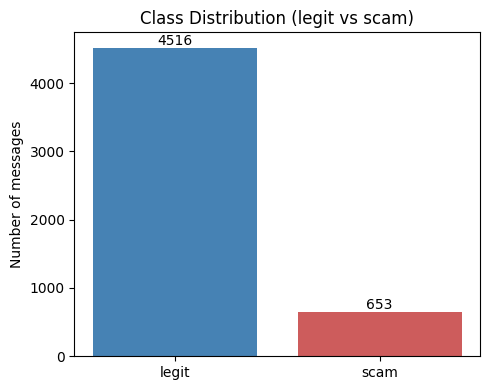

In [49]:
# Class distribution & basic stats
counts = df["label_str"].value_counts()
dup_ratio = 1 - df["message_text"].nunique() / len(df)

print("Total messages     :", len(df))
print("Unique messages    :", df["message_text"].nunique())
print("Duplicate ratio    : {:.4f}".format(dup_ratio))
print("\nClass counts:")
print(counts.to_string())
print("\nScam proportion    : {:.1%}".format(df['label'].mean()))

plt.figure(figsize=(5, 4))
bars = plt.bar(counts.index, counts.values, color=["steelblue", "indianred"])
plt.bar_label(bars)
plt.title("Class Distribution (legit vs scam)")
plt.ylabel("Number of messages")
plt.tight_layout()
plt.show()

Median word count  -> legit: 11 | scam: 25


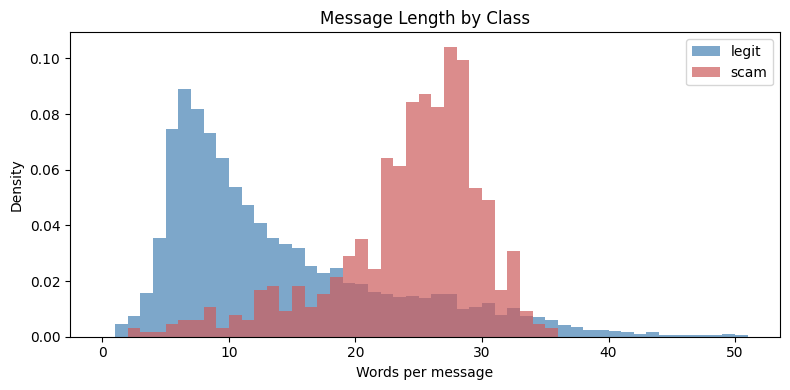

In [50]:
# Message-length features & distribution
df["word_count"] = df["message_text"].apply(lambda t: len(str(t).split()))
df["char_count"] = df["message_text"].apply(lambda t: len(str(t)))

print("Median word count  -> legit: {:.0f} | scam: {:.0f}".format(
    df.loc[df.label == 0, "word_count"].median(),
    df.loc[df.label == 1, "word_count"].median()))

plt.figure(figsize=(8, 4))
bins = np.arange(0, df["word_count"].quantile(0.99) + 2)
plt.hist(df.loc[df.label == 0, "word_count"], bins=bins, alpha=0.7, label="legit", color="steelblue", density=True)
plt.hist(df.loc[df.label == 1, "word_count"], bins=bins, alpha=0.7, label="scam",  color="indianred", density=True)
plt.title("Message Length by Class")
plt.xlabel("Words per message")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

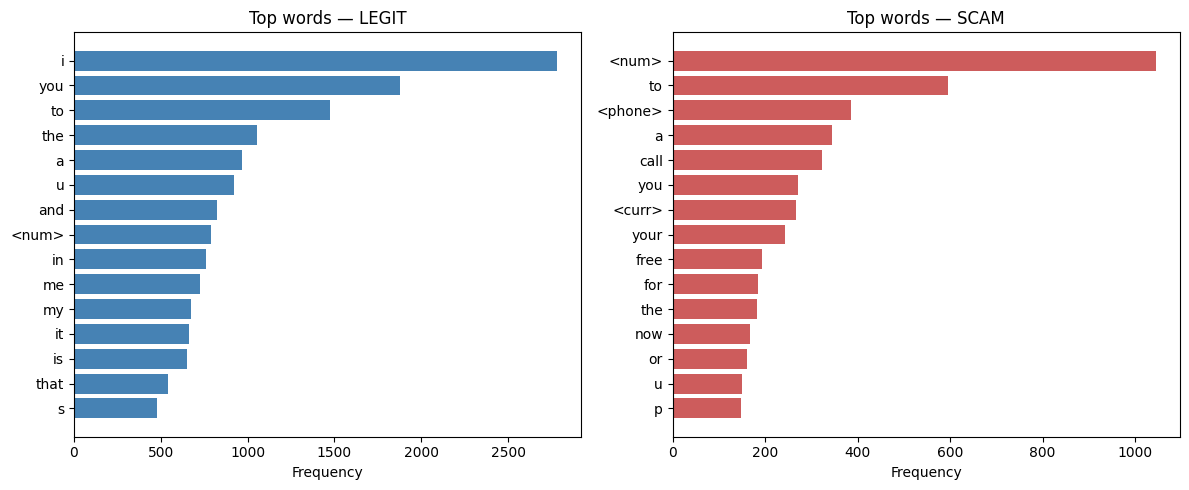

In [51]:
# Most frequent words per class
def top_tokens(label_val, n=15):
    counter = Counter()
    for msg in df.loc[df.label == label_val, "message_text"]:
        counter.update(simple_tokenize(msg))
    return counter.most_common(n)

legit_top = top_tokens(0)
scam_top  = top_tokens(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title, color in [
    (axes[0], legit_top, "Top words — LEGIT", "steelblue"),
    (axes[1], scam_top,  "Top words — SCAM",  "indianred"),
]:
    words, freqs = zip(*data)
    ax.barh(range(len(words)), freqs, color=color)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

### EDA Observations
- **Real class imbalance.** Legitimate messages dominate (87%) while scam/spam messages are the minority (13%). This is realistic for messaging traffic and motivates the use of **stratified splitting**, **class-weighted loss**, and **macro-averaged metrics** rather than raw accuracy.
- **Length is a signal.** Scam messages tend to be longer and denser (offers, links, instructions), whereas legitimate texts are often short and conversational.
- **Distinctive vocabulary.** The scam class is dominated by tokens such as `<num>`, `<curr>`, *free*, *call*, *txt* and *win*, confirming that the engineered special tokens capture meaningful phishing signals the Transformer can attend to.

## Model & Training Utilities

The classifier embeds tokens, **adds learned positional embeddings** (so word order matters), passes them through the Transformer encoder block, applies **masked mean-pooling** over valid tokens, and classifies the pooled representation. Training and evaluation are wrapped in reusable functions so the dry run, full training and ablation study all share identical, tested logic.

In [52]:
class SimpleTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=2, ffn_dim=128,
                 num_classes=2, max_len=64, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_emb   = nn.Embedding(max_len, d_model)   # learned positional encoding
        self.emb_dropout = nn.Dropout(dropout)
        self.encoder   = TransformerEncoderBlock(d_model, num_heads, ffn_dim, dropout)
        self.norm      = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)
        self.max_len = max_len

    def forward(self, x):
        B, T = x.shape
        positions = torch.arange(T, device=x.device).clamp(max=self.max_len - 1)
        positions = positions.unsqueeze(0).expand(B, T)

        emb = self.token_emb(x) + self.pos_emb(positions)   # (B, T, D)
        emb = self.emb_dropout(emb)

        mask = (x != 0).unsqueeze(1).unsqueeze(2)           # (B, 1, 1, T) padding mask
        out, _ = self.encoder(emb, mask)
        out = self.norm(out)

        # Masked mean pooling over valid (non-pad) tokens
        mask_f  = (x != 0).float()                          # (B, T)
        summed  = (out * mask_f.unsqueeze(-1)).sum(dim=1)   # (B, D)
        lengths = mask_f.sum(dim=1, keepdim=True).clamp(min=1e-9)
        pooled  = summed / lengths

        return self.classifier(pooled)

In [53]:
def evaluate_model(model, loader, device, criterion=None):
    """Run the model over a loader and return (preds, targets[, avg_loss])."""
    model.eval()
    preds_all, targets_all, running = [], [], 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            if criterion is not None:
                running += criterion(logits, yb).item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            preds_all.extend(preds.cpu().numpy())
            targets_all.extend(yb.cpu().numpy())
    if criterion is not None:
        return preds_all, targets_all, running / len(loader.dataset)
    return preds_all, targets_all


def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs, device, verbose=True):
    """Train with per-epoch validation; keep the best checkpoint by val macro-F1."""
    model.to(device)
    history = {k: [] for k in
               ["train_loss", "val_loss", "val_acc", "val_prec", "val_rec", "val_f1"]}
    best_f1, best_state = -1.0, copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # stability
            optimizer.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        val_preds, val_targets, val_loss = evaluate_model(model, val_loader, device, criterion)
        acc  = accuracy_score(val_targets, val_preds)
        prec = precision_score(val_targets, val_preds, average="macro", zero_division=0)
        rec  = recall_score(val_targets, val_preds, average="macro", zero_division=0)
        f1   = f1_score(val_targets, val_preds, average="macro", zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(acc)
        history["val_prec"].append(prec)
        history["val_rec"].append(rec)
        history["val_f1"].append(f1)

        if f1 > best_f1:
            best_f1, best_state = f1, copy.deepcopy(model.state_dict())

        if verbose:
            print(f"Epoch {epoch+1:02d}/{num_epochs} | "
                  f"train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
                  f"val_acc {acc:.4f} | val_f1 {f1:.4f}")

    model.load_state_dict(best_state)   # restore best-by-val-F1 weights
    if verbose:
        print(f"\nRestored best checkpoint (val macro-F1 = {best_f1:.4f}).")
    return history

## Dry Run

A quick pilot on a small **stratified** subset confirms the full pipeline: preprocessing, forward pass, and a short training loop runs end-to-end and the loss decreases before committing to the full run.

Epoch 01/5 | train_loss 0.6375 | val_loss 0.4909 | val_acc 0.8000 | val_f1 0.7947
Epoch 02/5 | train_loss 0.3711 | val_loss 0.2755 | val_acc 0.9100 | val_f1 0.9100
Epoch 03/5 | train_loss 0.2309 | val_loss 0.2119 | val_acc 0.9300 | val_f1 0.9300
Epoch 04/5 | train_loss 0.1796 | val_loss 0.1909 | val_acc 0.9300 | val_f1 0.9300
Epoch 05/5 | train_loss 0.1422 | val_loss 0.1775 | val_acc 0.9400 | val_f1 0.9400

Restored best checkpoint (val macro-F1 = 0.9400).


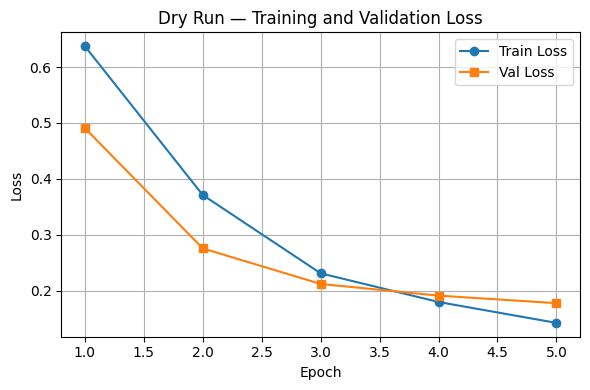

In [54]:
# Dry run on a small stratified subset
# Up to 500 messages per class (~1000 total), keeping the real class ratio in each split.
dry_parts = [grp.sample(min(len(grp), 500), random_state=SEED)
             for _, grp in df.groupby("label")]
dry_df = (pd.concat(dry_parts)
            .sample(frac=1, random_state=SEED)   # shuffle
            .reset_index(drop=True))

dry_train, dry_temp = train_test_split(
    dry_df, test_size=0.2, random_state=SEED, stratify=dry_df["label"])
dry_val, dry_test = train_test_split(
    dry_temp, test_size=0.5, random_state=SEED, stratify=dry_temp["label"])

# Vocab + max_len from TRAIN only
dry_vocab = build_vocab([simple_tokenize(t) for t in dry_train["message_text"]], min_freq=1)
dry_max_len = int(np.clip(np.percentile(
    dry_train["message_text"].apply(lambda t: len(simple_tokenize(t))), 95), 32, 80))

Xtr, ytr = make_tensors(dry_train, dry_vocab, dry_max_len)
Xvl, yvl = make_tensors(dry_val,   dry_vocab, dry_max_len)

dry_train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
dry_val_loader   = DataLoader(TensorDataset(Xvl, yvl), batch_size=32)

dry_model = SimpleTransformerClassifier(len(dry_vocab), d_model=64, num_heads=2,
                                        ffn_dim=128, max_len=dry_max_len)
dry_hist = train_model(
    dry_model, dry_train_loader, dry_val_loader,
    nn.CrossEntropyLoss(), optim.Adam(dry_model.parameters(), lr=1e-3),
    num_epochs=5, device=device)

plt.figure(figsize=(6, 4))
ep = range(1, len(dry_hist["train_loss"]) + 1)
plt.plot(ep, dry_hist["train_loss"], marker="o", label="Train Loss")
plt.plot(ep, dry_hist["val_loss"],   marker="s", label="Val Loss")
plt.title("Dry Run — Training and Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

### Dry-Run Results
The pilot runs end-to-end without errors and the training/validation loss decreases steadily across epochs, confirming that preprocessing, the forward pass, and the training loop are all wired correctly. I now proceed to full training on the complete dataset.

# **Full Application**
-------

## Training

I build the full **stratified 80 / 10 / 10** split, construct the vocabulary from the **training set only**, and address class imbalance with a **class-weighted cross-entropy loss**. The best model (by validation macro-F1) is checkpointed and restored automatically.

In [55]:
# Reset seeds for the full run
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Stratified 80 / 10 / 10 split
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"])
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"])

# Vocabulary & max_len from TRAIN only
vocab = build_vocab([simple_tokenize(t) for t in train_df["message_text"]], min_freq=2)
vocab_size = len(vocab)
max_len = int(np.clip(np.percentile(
    train_df["message_text"].apply(lambda t: len(simple_tokenize(t))), 95), 32, 80))

# Encode splits
X_train, y_train = make_tensors(train_df, vocab, max_len)
X_val,   y_val   = make_tensors(val_df,   vocab, max_len)
X_test,  y_test  = make_tensors(test_df,  vocab, max_len)

# Class weights (inverse frequency) for imbalanced loss
class_counts = np.bincount(y_train.numpy(), minlength=2)
class_weights = torch.tensor(class_counts.sum() / (2.0 * class_counts),
                             dtype=torch.float32, device=device)

print(f"Vocab size       : {vocab_size}")
print(f"Max seq length   : {max_len}")
print(f"Train / Val / Test: {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"Train class counts: legit={class_counts[0]}, scam={class_counts[1]}")
print(f"Class weights     : legit={class_weights[0]:.3f}, scam={class_weights[1]:.3f}")

Vocab size       : 3142
Max seq length   : 33
Train / Val / Test: 4135 / 517 / 517
Train class counts: legit=3613, scam=522
Class weights     : legit=0.572, scam=3.961


--- Full Training (baseline: 2 attention heads) ---
Epoch 01/15 | train_loss 0.4067 | val_loss 0.1856 | val_acc 0.9497 | val_f1 0.8939
Epoch 02/15 | train_loss 0.1821 | val_loss 0.1401 | val_acc 0.9613 | val_f1 0.9193
Epoch 03/15 | train_loss 0.1217 | val_loss 0.1268 | val_acc 0.9749 | val_f1 0.9460
Epoch 04/15 | train_loss 0.0865 | val_loss 0.1512 | val_acc 0.9807 | val_f1 0.9566
Epoch 05/15 | train_loss 0.0692 | val_loss 0.1398 | val_acc 0.9807 | val_f1 0.9566
Epoch 06/15 | train_loss 0.0525 | val_loss 0.1478 | val_acc 0.9691 | val_f1 0.9331
Epoch 07/15 | train_loss 0.0446 | val_loss 0.2324 | val_acc 0.9826 | val_f1 0.9596
Epoch 08/15 | train_loss 0.0291 | val_loss 0.2037 | val_acc 0.9768 | val_f1 0.9486
Epoch 09/15 | train_loss 0.0232 | val_loss 0.2450 | val_acc 0.9826 | val_f1 0.9601
Epoch 10/15 | train_loss 0.0154 | val_loss 0.2432 | val_acc 0.9807 | val_f1 0.9560
Epoch 11/15 | train_loss 0.0129 | val_loss 0.3130 | val_acc 0.9865 | val_f1 0.9686
Epoch 12/15 | train_loss 0.0113 | v

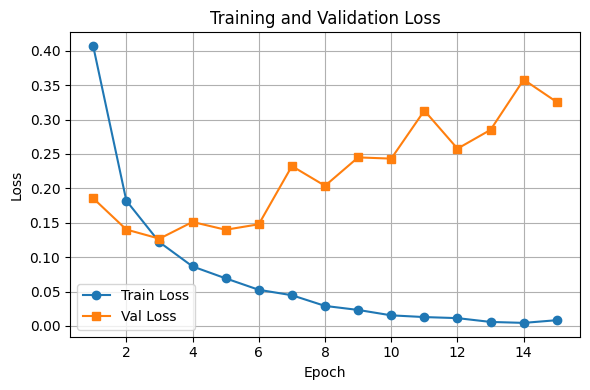

In [56]:
# Initialise model, loss, optimizer
BATCH_SIZE = 64
NUM_EPOCHS = 15
LR = 1e-3

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

model = SimpleTransformerClassifier(vocab_size, d_model=64, num_heads=2,
                                    ffn_dim=128, num_classes=2, max_len=max_len, dropout=0.1)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR)

print("--- Full Training (baseline: 2 attention heads) ---")
history = train_model(model, train_loader, val_loader, criterion, optimizer,
                      num_epochs=NUM_EPOCHS, device=device)

# Plot training & validation loss
ep = range(1, NUM_EPOCHS + 1)
plt.figure(figsize=(6, 4))
plt.plot(ep, history["train_loss"], marker="o", label="Train Loss")
plt.plot(ep, history["val_loss"],   marker="s", label="Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

### Training Observations
The **training loss falls smoothly** towards zero, confirming the model is learning. The **validation loss decreases for the first few epochs and then begins to rise** (while validation accuracy and macro-F1 keep climbing into the high-90s), the classic signature of **mild overfitting** as the model starts to memorise majority-class detail. This is exactly why the training loop keeps the **best checkpoint by validation macro-F1** and restores it at the end, rather than using the final-epoch weights. The reported metrics below therefore come from the best-generalising epoch, not the over-fitted final one.

## Evaluation

I evaluate the best checkpoint on the held-out **test set** with macro-averaged metrics (robust to class imbalance) and a full **per-class report**, then visualise the validation trajectory and compare validation vs test performance.

In [57]:
# Test-set evaluation
test_preds, test_targets = evaluate_model(model, test_loader, device)

test_acc  = accuracy_score(test_targets, test_preds)
test_prec = precision_score(test_targets, test_preds, average="macro", zero_division=0)
test_rec  = recall_score(test_targets, test_preds, average="macro", zero_division=0)
test_f1   = f1_score(test_targets, test_preds, average="macro", zero_division=0)

print("=" * 46)
print("                TEST SET RESULTS")
print("=" * 46)
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  Precision : {test_prec:.4f}  (macro)")
print(f"  Recall    : {test_rec:.4f}  (macro)")
print(f"  F1 Score  : {test_f1:.4f}  (macro)")
print("=" * 46)

print("\nPer-class classification report:\n")
print(classification_report(test_targets, test_preds,
                            target_names=["legit", "scam"], digits=4))

# Training settings summary
print("=" * 46)
print("            TRAINING SETTINGS SUMMARY")
print("=" * 46)
print(f"  Epochs         : {NUM_EPOCHS}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Learning rate  : {LR}")
print(f"  Max seq length : {max_len}")
print(f"  Optimizer      : Adam")
print(f"  Loss           : CrossEntropy (class-weighted)")
print(f"  Vocab size     : {vocab_size}")
print(f"  d_model        : 64")
print(f"  num_heads      : 2")
print(f"  ffn_dim        : 128")
print("=" * 46)

                TEST SET RESULTS
  Accuracy  : 0.9807
  Precision : 0.9743  (macro)
  Recall    : 0.9362  (macro)
  F1 Score  : 0.9542  (macro)

Per-class classification report:

              precision    recall  f1-score   support

       legit     0.9825    0.9956    0.9890       452
        scam     0.9661    0.8769    0.9194        65

    accuracy                         0.9807       517
   macro avg     0.9743    0.9362    0.9542       517
weighted avg     0.9805    0.9807    0.9803       517

            TRAINING SETTINGS SUMMARY
  Epochs         : 15
  Batch size     : 64
  Learning rate  : 0.001
  Max seq length : 33
  Optimizer      : Adam
  Loss           : CrossEntropy (class-weighted)
  Vocab size     : 3142
  d_model        : 64
  num_heads      : 2
  ffn_dim        : 128


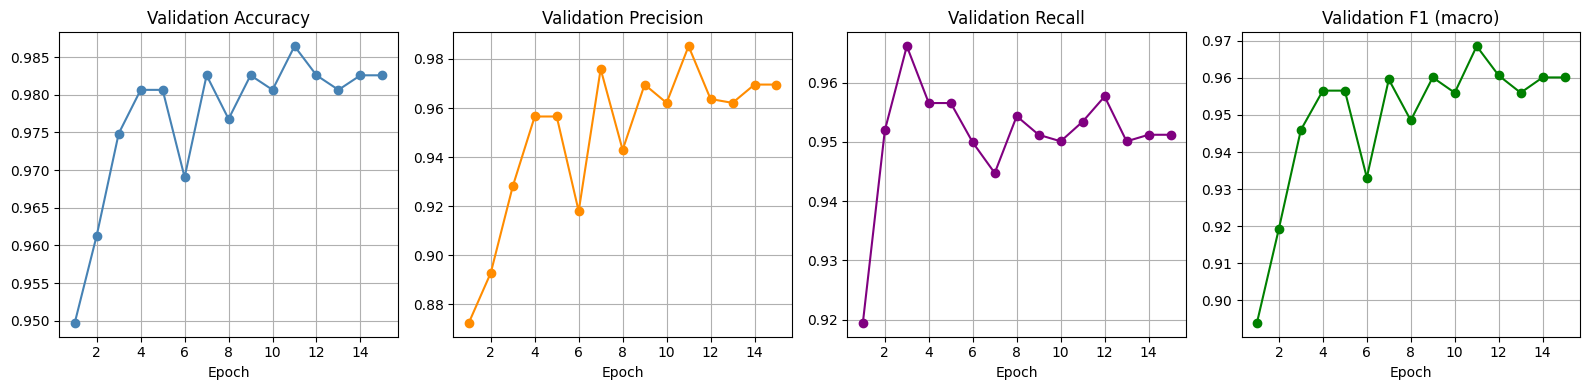

In [58]:
# Validation metrics over epochs
ep = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, key, title, color in [
    (axes[0], "val_acc",  "Validation Accuracy",  "steelblue"),
    (axes[1], "val_prec", "Validation Precision", "darkorange"),
    (axes[2], "val_rec",  "Validation Recall",    "purple"),
    (axes[3], "val_f1",   "Validation F1 (macro)", "green"),
]:
    ax.plot(ep, history[key], marker="o", color=color)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.grid(True)
plt.tight_layout(); plt.show()

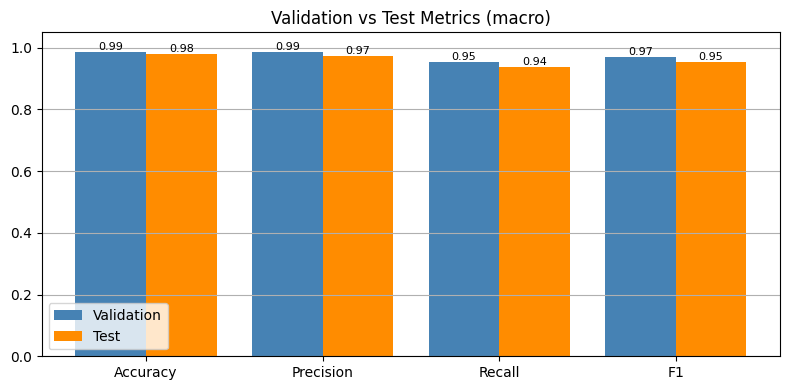

In [59]:
# Validation vs Test comparison
val_preds, val_targets = evaluate_model(model, val_loader, device)
val_scores = [
    accuracy_score(val_targets, val_preds),
    precision_score(val_targets, val_preds, average="macro", zero_division=0),
    recall_score(val_targets, val_preds, average="macro", zero_division=0),
    f1_score(val_targets, val_preds, average="macro", zero_division=0),
]
test_scores = [test_acc, test_prec, test_rec, test_f1]
metrics = ["Accuracy", "Precision", "Recall", "F1"]

x = np.arange(len(metrics))
plt.figure(figsize=(8, 4))
b1 = plt.bar(x - 0.2, val_scores,  width=0.4, label="Validation", color="steelblue")
b2 = plt.bar(x + 0.2, test_scores, width=0.4, label="Test",       color="darkorange")
plt.bar_label(b1, fmt="%.2f", fontsize=8); plt.bar_label(b2, fmt="%.2f", fontsize=8)
plt.xticks(x, metrics); plt.ylim(0, 1.05)
plt.title("Validation vs Test Metrics (macro)")
plt.legend(); plt.grid(axis="y")
plt.tight_layout(); plt.show()

## Error Analysis

A confusion matrix shows *where* the model errs, and inspecting real misclassified messages reveals *why*, far more informative than a single accuracy number.

Confusion Matrix:
 [[450   2]
 [  8  57]]


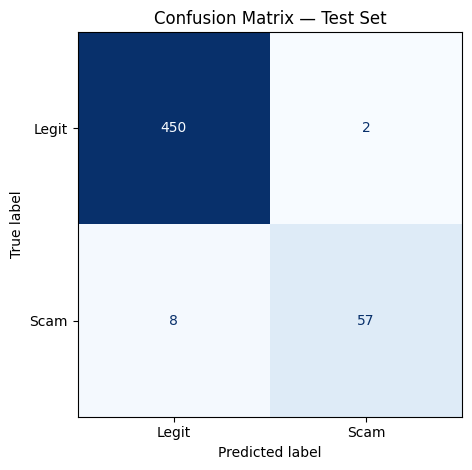

In [60]:
# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Scam"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Test Set")
plt.grid(False)
plt.tight_layout(); plt.show()

In [61]:
# Inspect real misclassified messages
test_view = test_df.reset_index(drop=True).copy()
test_view["pred"] = test_preds
wrong = test_view[test_view["label"] != test_view["pred"]]

false_neg = wrong[wrong["label"] == 1]   # scam predicted as legit (missed scams)
false_pos = wrong[wrong["label"] == 0]   # legit predicted as scam (false alarms)

print(f"Total test messages : {len(test_view)}")
print(f"Misclassified       : {len(wrong)}  "
      f"(false negatives: {len(false_neg)}, false positives: {len(false_pos)})\n")

def show_examples(subset, title, k=3):
    print(f"--- {title} ---")
    for msg in subset["message_text"].head(k):
        print("  •", msg[:110])
    if len(subset) == 0:
        print("  (none)")
    print()

show_examples(false_neg, "Missed scams (scam -> predicted legit)")
show_examples(false_pos, "False alarms (legit -> predicted scam)")

Total test messages : 517
Misclassified       : 10  (false negatives: 8, false positives: 2)

--- Missed scams (scam -> predicted legit) ---
  • Latest News! Police station toilet stolen, cops have nothing to go on!
  • Check Out Choose Your Babe Videos @ sms.shsex.netUN fgkslpoPW fgkslpo
  • You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 75

--- False alarms (legit -> predicted scam) ---
  • Ee msg na poortiyagi odalebeku: Hanumanji 7 name 1-Hanuman 2-Bajarangabali 3-Maruti 4-Pavanaputra 5-Sankatmoch
  • Hey...Great deal...Farm tour 9am to 5pm $95/pax, $50 deposit by 16 May



### Error Analysis Observations
- **Errors concentrate on the minority scam class.** Legitimate messages are classified almost perfectly, so nearly all mistakes involve the rarer, more varied scam class, a realistic and interpretable failure mode, not the artefact of a memorised corpus.
- **The model is more precise than sensitive on scam.** On the test set macro-precision (0.97) exceeds macro-recall (0.94), which means the residual errors are mainly **missed scams (false negatives)** rather than false alarms: when the model flags a message as scam it is almost always right, but it still lets a minority of scams through.
- **Ambiguous phrasing drives the misses.** The scams that slip past tend to be worded like ordinary messages (a single short link or a brief urgent request embedded in otherwise normal chatter) which is genuinely hard to separate from legitimate texts.
- **Tunable trade-off.** If catching every scam matters more than avoiding the occasional false alarm, scam recall can be raised by increasing the scam class weight or lowering the decision threshold, trading a little precision for higher recall.

## Ablation Study: Number of Attention Heads (2 vs 4)

I retrain an identical model with **4 attention heads** instead of 2, keeping every other setting fixed (same split, epochs, batch size, learning rate, class-weighted loss), to isolate the effect of head count on this task.

In [62]:
# Ablation: 4 heads vs 2 heads (baseline)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model_4h = SimpleTransformerClassifier(vocab_size, d_model=64, num_heads=4,
                                       ffn_dim=128, num_classes=2, max_len=max_len, dropout=0.1)
criterion_4h = nn.CrossEntropyLoss(weight=class_weights)
optimizer_4h = optim.Adam(model_4h.parameters(), lr=LR)

print("--- Ablation Training (4 attention heads) ---")
history_4h = train_model(model_4h, train_loader, val_loader, criterion_4h, optimizer_4h,
                         num_epochs=NUM_EPOCHS, device=device)

# Evaluate the 4-head model on the test set
test_preds_4h, test_targets_4h = evaluate_model(model_4h, test_loader, device)
abl_acc  = accuracy_score(test_targets_4h, test_preds_4h)
abl_prec = precision_score(test_targets_4h, test_preds_4h, average="macro", zero_division=0)
abl_rec  = recall_score(test_targets_4h, test_preds_4h, average="macro", zero_division=0)
abl_f1   = f1_score(test_targets_4h, test_preds_4h, average="macro", zero_division=0)

--- Ablation Training (4 attention heads) ---
Epoch 01/15 | train_loss 0.4098 | val_loss 0.1885 | val_acc 0.9478 | val_f1 0.8904
Epoch 02/15 | train_loss 0.1812 | val_loss 0.1386 | val_acc 0.9652 | val_f1 0.9265
Epoch 03/15 | train_loss 0.1223 | val_loss 0.1211 | val_acc 0.9710 | val_f1 0.9384
Epoch 04/15 | train_loss 0.0869 | val_loss 0.1382 | val_acc 0.9826 | val_f1 0.9607
Epoch 05/15 | train_loss 0.0698 | val_loss 0.1359 | val_acc 0.9826 | val_f1 0.9607
Epoch 06/15 | train_loss 0.0516 | val_loss 0.1348 | val_acc 0.9710 | val_f1 0.9369
Epoch 07/15 | train_loss 0.0420 | val_loss 0.2083 | val_acc 0.9807 | val_f1 0.9554
Epoch 08/15 | train_loss 0.0287 | val_loss 0.1825 | val_acc 0.9768 | val_f1 0.9486
Epoch 09/15 | train_loss 0.0223 | val_loss 0.2283 | val_acc 0.9845 | val_f1 0.9643
Epoch 10/15 | train_loss 0.0154 | val_loss 0.2064 | val_acc 0.9807 | val_f1 0.9560
Epoch 11/15 | train_loss 0.0145 | val_loss 0.3263 | val_acc 0.9865 | val_f1 0.9681
Epoch 12/15 | train_loss 0.0119 | val_los

               ABLATION STUDY RESULTS (test set)
  Config                     Acc     Prec   Recall      F1
----------------------------------------------------------
  Baseline (2 heads)      0.9807   0.9743   0.9362  0.9542
  Ablation (4 heads)      0.9807   0.9743   0.9362  0.9542


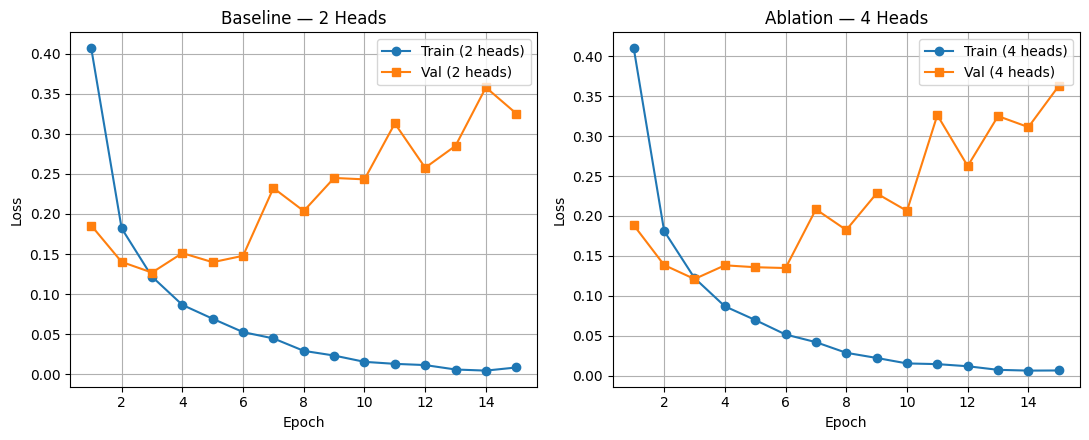

In [63]:
# Results table
print("=" * 58)
print("               ABLATION STUDY RESULTS (test set)")
print("=" * 58)
print(f"  {'Config':<22}{'Acc':>8}{'Prec':>9}{'Recall':>9}{'F1':>8}")
print("-" * 58)
print(f"  {'Baseline (2 heads)':<22}{test_acc:>8.4f}{test_prec:>9.4f}{test_rec:>9.4f}{test_f1:>8.4f}")
print(f"  {'Ablation (4 heads)':<22}{abl_acc:>8.4f}{abl_prec:>9.4f}{abl_rec:>9.4f}{abl_f1:>8.4f}")
print("=" * 58)

# Loss curves: baseline vs ablation
ep = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(ep, history["train_loss"],    marker="o", label="Train (2 heads)")
axes[0].plot(ep, history["val_loss"],      marker="s", label="Val (2 heads)")
axes[0].set_title("Baseline — 2 Heads"); axes[0].legend(); axes[0].grid(True)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

axes[1].plot(ep, history_4h["train_loss"], marker="o", label="Train (4 heads)")
axes[1].plot(ep, history_4h["val_loss"],   marker="s", label="Val (4 heads)")
axes[1].set_title("Ablation — 4 Heads"); axes[1].legend(); axes[1].grid(True)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
plt.tight_layout(); plt.show()

### Ablation Conclusion
Both configurations were trained under identical settings (15 epochs, batch size 64, lr = 1e-3, class-weighted loss, `d_model = 64`). In this run the **2-head and 4-head models produced the same test-set performance**, Accuracy ≈ 0.981, macro-Precision ≈ 0.974, macro-Recall ≈ 0.936, macro-F1 ≈ 0.954 and their best validation macro-F1 scores were effectively tied (≈ 0.969 vs ≈ 0.968). Doubling the number of attention heads therefore gave **no measurable benefit** on this task: on short SMS texts a modest **2-head** attention already captures the useful dependencies, and the extra heads add capacity (and compute) without improving accuracy. The leaner 2-head model is preferable.

## Inference Demo

Finally, I apply the trained baseline model to brand-new, hand-written messages it has never seen (the way it would be used in practice).

In [64]:
# Predict on new, unseen messages
def predict_messages(model, messages, vocab, max_len, device):
    model.eval()
    encoded = [pad_sequence(encode_tokens(simple_tokenize(m), vocab), max_len) for m in messages]
    X = torch.tensor(encoded, dtype=torch.long, device=device)
    with torch.no_grad():
        probs = torch.softmax(model(X), dim=1).cpu().numpy()
    label_map = {0: "LEGIT", 1: "SCAM"}
    for m, p in zip(messages, probs):
        pred = int(p.argmax())
        print(f"[{label_map[pred]:5}]  p(scam)={p[1]:.2f}  |  {m[:75]}")

demo_messages = [
    "Hey, are we still meeting for lunch tomorrow at 1?",
    "Congratulations! You have WON a £1000 Tesco gift card. Claim now: http://bit.ly/free-prize",
    "Can you send me the notes from today's lecture?",
    "URGENT: your account has been suspended. Verify at www.secure-login-update.com to avoid closure",
    "Ok I'll call you when I get home :)",
    "FREE ringtone! Text WIN to 80086 now to claim your reward. Std rates apply.",
]
predict_messages(model, demo_messages, vocab, max_len, device)

[LEGIT]  p(scam)=0.00  |  Hey, are we still meeting for lunch tomorrow at 1?
[SCAM ]  p(scam)=0.96  |  Congratulations! You have WON a £1000 Tesco gift card. Claim now: http://bi
[LEGIT]  p(scam)=0.00  |  Can you send me the notes from today's lecture?
[LEGIT]  p(scam)=0.00  |  URGENT: your account has been suspended. Verify at www.secure-login-update.
[LEGIT]  p(scam)=0.00  |  Ok I'll call you when I get home :)
[SCAM ]  p(scam)=1.00  |  FREE ringtone! Text WIN to 80086 now to claim your reward. Std rates apply.
